<a href="https://colab.research.google.com/github/MarioRojasV/CNN_Models_Comparison_Bird_Classification/blob/main/src/teachable_machine_model/Teachable_Machine_Birds_COMPDES_2026_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tf_keras --quiet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import tf_keras
from sklearn.metrics import confusion_matrix, classification_report

Mounted at /content/drive


In [3]:
# RUTAS DEL MODELO DE TEACHABLE MACHINE

MODEL_PATH = "/content/drive/MyDrive/Universidad/COMPDES2026_Aves_CR/Resultados_TeachableMachine/keras_model.h5"
LABELS_PATH = "/content/drive/MyDrive/Universidad/COMPDES2026_Aves_CR/Resultados_TeachableMachine/labels.txt"

# RUTAS DEL DATASET DE PRUEBA

TESTING_PATH = "/content/drive/MyDrive/Universidad/COMPDES2026_Aves_CR/Dataset/Testing_set"
TEST_REGULAR_PATH = TESTING_PATH + "/Regular_photos"
TEST_FLYING_PATH = TESTING_PATH + "/Flying_photos"

# CARPETA DONDE SE GUARDAN LAS FIGURAS PARA EL PAPER

RESULTS_PATH = "/content/drive/MyDrive/Universidad/COMPDES2026_Aves_CR/Resultados_TeachableMachine"
os.makedirs(RESULTS_PATH, exist_ok=True)

# PARÁMETROS GENERALES

IMG_SIZE = (224, 224)

# Etiquetas legibles para las figuras (mismo orden usado en la CNN baseline)
DISPLAY_LABELS = [
    "Quiscalus mexicanus\n(hembra)",
    "Turdus grayi"
]

In [4]:
model = tf_keras.models.load_model(MODEL_PATH, compile=False)

with open(LABELS_PATH, "r") as f:
    tm_labels = [linea.strip().split(" ", 1)[1] for linea in f.readlines()]

print("Clases reconocidas por el modelo de Teachable Machine:")
for indice, etiqueta in enumerate(tm_labels):
    print(f"  {indice}: {etiqueta}")

Clases reconocidas por el modelo de Teachable Machine:
  0: Q. mexicanus
  1: T. grayi


In [5]:
def encontrar_indice_tm(nombre_carpeta, tm_labels):
    """Empareja una carpeta del dataset con su clase en Teachable Machine,
    comparando el epíteto de la especie (segunda palabra del nombre científico)."""
    carpeta_normalizada = nombre_carpeta.lower()
    for indice, etiqueta in enumerate(tm_labels):
        especie = etiqueta.lower().split()[-1].strip(".")
        if especie in carpeta_normalizada:
            return indice
    return None


def construir_mapeo(test_path, tm_labels):
    carpetas = sorted(
        nombre for nombre in os.listdir(test_path)
        if os.path.isdir(os.path.join(test_path, nombre))
    )
    return {carpeta: encontrar_indice_tm(carpeta, tm_labels) for carpeta in carpetas}


def verificar_mapeo(mapeo, tm_labels, nombre_dataset):
    print(f"Mapeo carpeta -> clase de Teachable Machine ({nombre_dataset}):")
    for carpeta, indice in mapeo.items():
        etiqueta = tm_labels[indice] if indice is not None else "NO ENCONTRADO"
        print(f"  {carpeta}  ->  {etiqueta}")

    assert all(v is not None for v in mapeo.values()), \
        "Hay carpetas sin emparejar. Revisa los nombres antes de continuar."

In [6]:
def preprocesar_imagen(ruta_imagen, size=IMG_SIZE):
    """Recorte centrado, redimensionado LANCZOS y normalización a [-1, 1],
    igual que el preprocesamiento oficial de Teachable Machine."""
    imagen = Image.open(ruta_imagen).convert("RGB")
    imagen = ImageOps.fit(imagen, size, Image.Resampling.LANCZOS)
    arreglo = np.asarray(imagen).astype(np.float32)
    arreglo_normalizado = (arreglo / 127.5) - 1
    return np.expand_dims(arreglo_normalizado, axis=0)


def evaluar_modelo_tm(test_path, mapeo_carpetas, modelo):
    y_true = []
    y_pred = []
    y_probs = []

    for carpeta, indice_real in mapeo_carpetas.items():
        ruta_carpeta = os.path.join(test_path, carpeta)

        for nombre_archivo in sorted(os.listdir(ruta_carpeta)):
            ruta_imagen = os.path.join(ruta_carpeta, nombre_archivo)

            try:
                entrada = preprocesar_imagen(ruta_imagen)
            except Exception as error:
                print(f"No se pudo abrir {ruta_imagen}: {error}")
                continue
            prediccion = modelo.predict(entrada, verbose=0)
            y_true.append(indice_real)
            y_pred.append(int(np.argmax(prediccion)))
            y_probs.append(prediccion[0])

    return np.array(y_true), np.array(y_pred), np.array(y_probs)

In [7]:
def graficar_matriz_confusion(y_true, y_pred, labels, titulo, ruta_guardado, en_porcentaje=False):
    cm = confusion_matrix(y_true, y_pred)

    if en_porcentaje:
        datos = (cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]) * 100
        cmap, vmin, vmax = "Oranges", 0, 100
    else:
        datos = cm
        cmap, vmin, vmax = "Blues", None, None

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(datos, cmap=cmap, vmin=vmin, vmax=vmax)

    cbar = plt.colorbar(im)
    cbar.set_label("Porcentaje (%)" if en_porcentaje else "Cantidad de imágenes")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("Clase predicha", fontsize=12, fontweight="bold")
    ax.set_ylabel("Clase real", fontsize=12, fontweight="bold")
    ax.set_title(titulo, fontsize=13, fontweight="bold")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            texto = f"{cm[i, j]}\n({datos[i, j]:.1f}%)" if en_porcentaje else str(cm[i, j])
            ax.text(j, i, texto, ha="center", va="center",
                    fontsize=12 if en_porcentaje else 14,
                    fontweight="bold", color="black")

    plt.tight_layout()
    plt.savefig(ruta_guardado, dpi=300, bbox_inches="tight")
    plt.show()
    return cm


def analizar_confianza_por_categoria(y_true, y_pred, y_probs, titulo):
    confianza = y_probs[np.arange(len(y_pred)), y_pred]
    prob_clase_real = y_probs[np.arange(len(y_true)), y_true]
    perdida_por_imagen = -np.log(np.clip(prob_clase_real, 1e-7, 1.0))
    nombres_cortos = ["Q. mexicanus", "T. grayi"]

    print("=" * 65)
    print(f"ANÁLISIS DE CONFIANZA POR CATEGORÍA — {titulo}")
    print("=" * 65)

    for real in range(2):
        for predicha in range(2):
            mascara = (y_true == real) & (y_pred == predicha)
            n = int(mascara.sum())
            if n == 0:
                continue

            tipo = "✓ ACIERTO" if real == predicha else "✗ ERROR"
            conf    = confianza[mascara]
            perdida = perdida_por_imagen[mascara]
            print(f"\n{tipo} | Real: {nombres_cortos[real]}"
                  f"  →  Predicha: {nombres_cortos[predicha]}")
            print(f"  Cantidad de imágenes : {n}")
            print(f"  Confianza promedio   : {conf.mean()*100:.2f}%")
            print(f"  Confianza mínima     : {conf.min()*100:.2f}%")
            print(f"  Confianza máxima     : {conf.max()*100:.2f}%")
            print(f"  Pérdida promedio     : {perdida.mean():.4f}")

    print(f"\n  Pérdida global promedio: {perdida_por_imagen.mean():.4f}")
    print("=" * 65)

In [8]:
mapeo_regular = construir_mapeo(TEST_REGULAR_PATH, tm_labels)
verificar_mapeo(mapeo_regular, tm_labels, "Regular_photos")

Mapeo carpeta -> clase de Teachable Machine (Regular_photos):
  Quiscalus_mexicanus_testing_photos  ->  Q. mexicanus
  Turdus_grayi_testing_photos  ->  T. grayi


In [9]:
y_true_regular, y_pred_regular, y_probs_regular = evaluar_modelo_tm(
    TEST_REGULAR_PATH, mapeo_regular, model
)

test_accuracy = np.mean(y_true_regular == y_pred_regular)
test_loss     = -np.mean(np.log(np.clip(
    y_probs_regular[np.arange(len(y_true_regular)), y_true_regular], 1e-7, 1.0
)))

print("Test accuracy (Teachable Machine, Regular Photos):", round(float(test_accuracy), 4))
print("Test loss    (Teachable Machine, Regular Photos):", round(float(test_loss), 4))

Test accuracy (Teachable Machine, Regular Photos): 0.9125
Test loss    (Teachable Machine, Regular Photos): 0.2692


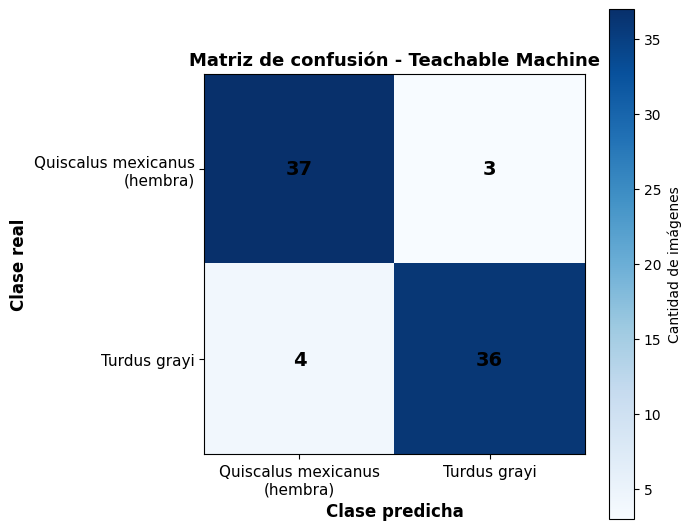

              precision    recall  f1-score   support

Q. mexicanus     0.9024    0.9250    0.9136        40
    T. grayi     0.9231    0.9000    0.9114        40

    accuracy                         0.9125        80
   macro avg     0.9128    0.9125    0.9125        80
weighted avg     0.9128    0.9125    0.9125        80



In [10]:
cm_regular = graficar_matriz_confusion(
    y_true_regular, y_pred_regular, DISPLAY_LABELS,
    "Matriz de confusión - Teachable Machine",
    RESULTS_PATH + "/Matriz_Confusion_TM_Regular.png"
)

print(classification_report(y_true_regular, y_pred_regular, target_names=tm_labels, digits=4))

In [11]:
mapeo_flying = construir_mapeo(TEST_FLYING_PATH, tm_labels)
verificar_mapeo(mapeo_flying, tm_labels, "Flying_photos")

Mapeo carpeta -> clase de Teachable Machine (Flying_photos):
  Quiscalus_mexicanus_flying  ->  Q. mexicanus
  Turdus_grayi_flying  ->  T. grayi


In [12]:
y_true_flying, y_pred_flying, y_probs_flying = evaluar_modelo_tm(
    TEST_FLYING_PATH, mapeo_flying, model
)

flying_accuracy = np.mean(y_true_flying == y_pred_flying)
flying_loss     = -np.mean(np.log(np.clip(
    y_probs_flying[np.arange(len(y_true_flying)), y_true_flying], 1e-7, 1.0
)))

print("Test accuracy (Teachable Machine, Flying Photos):", round(float(flying_accuracy), 4))
print("Test loss    (Teachable Machine, Flying Photos):", round(float(flying_loss), 4))

Test accuracy (Teachable Machine, Flying Photos): 0.7
Test loss    (Teachable Machine, Flying Photos): 1.2452


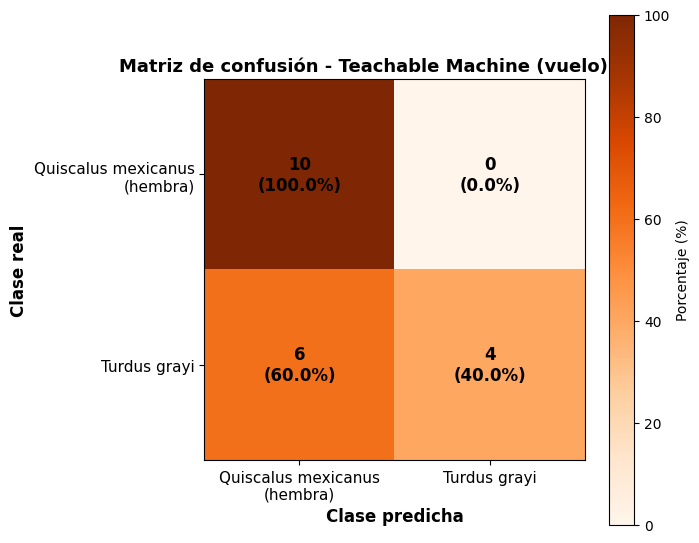

              precision    recall  f1-score   support

Q. mexicanus     0.6250    1.0000    0.7692        10
    T. grayi     1.0000    0.4000    0.5714        10

    accuracy                         0.7000        20
   macro avg     0.8125    0.7000    0.6703        20
weighted avg     0.8125    0.7000    0.6703        20



In [13]:
cm_flying = graficar_matriz_confusion(
    y_true_flying, y_pred_flying, DISPLAY_LABELS,
    "Matriz de confusión - Teachable Machine (vuelo)          ",
    RESULTS_PATH + "/Matriz_Confusion_TM_Flying.png",
    en_porcentaje=True
)

print(classification_report(y_true_flying, y_pred_flying, target_names=tm_labels, digits=4))

In [14]:
analizar_confianza_por_categoria(
    y_true_regular, y_pred_regular, y_probs_regular,
    "Teachable Machine — Fotos regulares"
)

ANÁLISIS DE CONFIANZA POR CATEGORÍA — Teachable Machine — Fotos regulares

✓ ACIERTO | Real: Q. mexicanus  →  Predicha: Q. mexicanus
  Cantidad de imágenes : 37
  Confianza promedio   : 98.22%
  Confianza mínima     : 68.05%
  Confianza máxima     : 100.00%
  Pérdida promedio     : 0.0202

✗ ERROR | Real: Q. mexicanus  →  Predicha: T. grayi
  Cantidad de imágenes : 3
  Confianza promedio   : 81.98%
  Confianza mínima     : 52.23%
  Confianza máxima     : 98.34%
  Pérdida promedio     : 2.6371

✗ ERROR | Real: T. grayi  →  Predicha: Q. mexicanus
  Cantidad de imágenes : 4
  Confianza promedio   : 90.43%
  Confianza mínima     : 80.02%
  Confianza máxima     : 98.93%
  Pérdida promedio     : 3.0929

✓ ACIERTO | Real: T. grayi  →  Predicha: T. grayi
  Cantidad de imágenes : 36
  Confianza promedio   : 98.67%
  Confianza mínima     : 82.24%
  Confianza máxima     : 100.00%
  Pérdida promedio     : 0.0139

  Pérdida global promedio: 0.2692


In [15]:
analizar_confianza_por_categoria(
    y_true_flying, y_pred_flying, y_probs_flying,
    "Teachable Machine — Fotografías en vuelo"
)

ANÁLISIS DE CONFIANZA POR CATEGORÍA — Teachable Machine — Fotografías en vuelo

✓ ACIERTO | Real: Q. mexicanus  →  Predicha: Q. mexicanus
  Cantidad de imágenes : 10
  Confianza promedio   : 99.94%
  Confianza mínima     : 99.74%
  Confianza máxima     : 100.00%
  Pérdida promedio     : 0.0006

✗ ERROR | Real: T. grayi  →  Predicha: Q. mexicanus
  Cantidad de imágenes : 6
  Confianza promedio   : 88.97%
  Confianza mínima     : 53.14%
  Confianza máxima     : 99.99%
  Pérdida promedio     : 4.0471

✓ ACIERTO | Real: T. grayi  →  Predicha: T. grayi
  Cantidad de imágenes : 4
  Confianza promedio   : 86.70%
  Confianza mínima     : 72.20%
  Confianza máxima     : 99.98%
  Pérdida promedio     : 0.1537

  Pérdida global promedio: 1.2452
